# Bread Quality Classification using CNN

**Machine Learning Project – Phase II · Idea 34 (Bakery Product Quality Classification)**

A CNN-based screening system that classifies **bread** as **Good Quality** vs
**Defective** (stale, burnt, undercooked or moldy). A custom CNN is benchmarked
against **two** transfer-learning models (**MobileNetV2** and **ResNet50**) using
accuracy, precision, recall, F1, ROC-AUC and **inference time**, with **Grad-CAM**
explainability and **error analysis**.

The system is framed as a **decision-support / screening tool that assists human
quality inspectors, not replaces them.**

### Dataset
**"Bread" – Good and Bad Classification of Bread (Triticum Aestivum)**
Das & Sarkar, Mendeley Data, DOI 10.17632/2cymbb4gt4.1, License CC BY 4.0.
Uploaded to Kaggle as a Dataset and attached to this notebook via **Add Input**.

> **Before running:**
> 1. **Add Input → Datasets** → add your uploaded bread dataset.
> 2. **Settings → Accelerator → GPU**.
> 3. **Settings → Internet → On** (needed to download the ImageNet weights for transfer learning).
> 4. **Run All**.

## 0. Imports and Configuration

In [13]:
import os, shutil, glob, random, hashlib, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_fscore_support)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [14]:
# ----------------------- CONFIGURATION -----------------------
# Point at the whole /kaggle/input tree; os.walk finds the labelled good/bad
# folders, so the exact nesting of your uploaded dataset does not matter.
INPUT_ROOTS = ["/kaggle/input"]

COMBINED_DIR = "/kaggle/working/dataset_combined"
SPLIT_DIR    = "/kaggle/working/dataset_split"
FIG_DIR      = "/kaggle/working/figures"
MODEL_DIR    = "/kaggle/working/models"
for d in (FIG_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

IMG_SIZE   = (160, 160)
BATCH_SIZE = 32
EPOCHS_CNN       = 25
EPOCHS_TL_HEAD   = 12
EPOCHS_TL_FT     = 6
SPLIT_RATIOS = (0.70, 0.15, 0.15)
AUTOTUNE = tf.data.AUTOTUNE

# Data-quality controls
DEDUP = True                  # remove exact-duplicate images (prevents train/test leakage)
MIN_UNIQUE_PER_CLASS = 60     # stop early if a dataset has too few real images per class
MAX_PER_CLASS = 1500          # cap images per class to keep training time reasonable (None = use all)

# Optional manual mapping: folder-name substring (lowercase) -> 'good' or 'defective'.
# Checked BEFORE the automatic keyword rules. Use this when a dataset's "good"
# folder isn't an obvious word (e.g. a bread dataset with folders 'bread' and
# 'moldy' -> set {"moldy": "defective", "bread": "good"}). Leave {} to rely on
# automatic detection (good/fresh/healthy vs bad/moldy/rotten/stale/burnt).
CLASS_OVERRIDES = {}

## 1. Explore the Dataset Structure
Print every folder with its image count so we can confirm the labelled class
folders before building the dataset.

In [15]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
for root in INPUT_ROOTS:
    for dp, dirs, files in os.walk(root):
        n = len([f for f in files if f.lower().endswith(IMG_EXTS)])
        depth = dp.replace(root, "").count("/")
        if n or depth <= 4:
            print("  " * depth, os.path.basename(dp) or dp, f"({n} images)")

 input (0 images)
   datasets (0 images)
     karansridhar (0 images)
       bakery-quality-classification (0 images)
         Bread (0 images)
           Good  (502 images)
              BAD (500 images)


## 2. Build the Binary Dataset
Each image is assigned to **good** or **defective** by matching keywords in its
folder name. This is robust to the dataset's nested layout.

In [16]:
def classify_folder(name):
    n = name.lower().replace(" ", "").replace("-", "").replace("_", "")
    for sub, label in CLASS_OVERRIDES.items():          # manual overrides first
        if sub.lower().replace(" ", "").replace("-", "").replace("_", "") in n:
            return label
    if any(k in n for k in ["good", "fresh", "nonmold", "notmold", "normal", "healthy"]):
        return "good"
    if any(k in n for k in ["bad", "mold", "stale", "rotten", "burnt", "defect", "spoil"]):
        return "defective"
    return None

def build_combined(input_roots, out_dir):
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    counts = {"good": 0, "defective": 0}
    for c in counts:
        os.makedirs(os.path.join(out_dir, c), exist_ok=True)
    skipped = []
    for root in input_roots:
        if not os.path.exists(root):
            continue
        for dp, _, files in os.walk(root):
            imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
            if not imgs:
                continue
            label = None
            for p in reversed(dp.replace("\\", "/").split("/")):
                label = classify_folder(p)
                if label:
                    break
            if label is None:
                skipped.append((dp, len(imgs))); continue
            for f in imgs:
                ext = os.path.splitext(f)[1].lower()
                shutil.copy(os.path.join(dp, f),
                            os.path.join(out_dir, label, f"{label}_{counts[label]:06d}{ext}"))
                counts[label] += 1
    return counts, skipped

counts, skipped = build_combined(INPUT_ROOTS, COMBINED_DIR)
print("After merging:", counts, "| total =", sum(counts.values()))
if skipped:
    print("Skipped (no good/defective keyword):")
    for d, n in skipped:
        print(f"  {n:>5}  {d}")

After merging: {'good': 502, 'defective': 500} | total = 1002


## 3. Data Cleaning & Quality Audit
We remove **corrupted/unreadable** images and (optionally) **exact-duplicate**
files. Crucially, we count how many *unique* images each class really has and
**stop with a clear message if a dataset is mostly duplicates** (which would make
training and evaluation meaningless due to train/test leakage).

In [17]:
def audit_and_clean(root, dedup=True):
    removed_corrupt, removed_dup = 0, 0
    unique_per_class, seen = {}, set()
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        uniq = 0
        for f in list(os.listdir(cls_dir)):
            path = os.path.join(cls_dir, f)
            try:                                   # 1) corrupted / unreadable
                with Image.open(path) as im:
                    im.verify()
            except Exception:
                os.remove(path); removed_corrupt += 1; continue
            with open(path, "rb") as fh:           # 2) exact duplicate (md5)
                h = hashlib.md5(fh.read()).hexdigest()
            if h in seen:
                if dedup:
                    os.remove(path); removed_dup += 1
            else:
                seen.add(h); uniq += 1
        unique_per_class[cls] = uniq
    return removed_corrupt, removed_dup, unique_per_class

rc, rd, unique_per_class = audit_and_clean(COMBINED_DIR, dedup=DEDUP)
print(f"Removed corrupted/unreadable : {rc}")
print(f"Removed exact duplicates     : {rd}  (DEDUP={DEDUP})")
print("Unique images per class      :", unique_per_class)

counts = {c: len(os.listdir(os.path.join(COMBINED_DIR, c)))
          for c in sorted(os.listdir(COMBINED_DIR))}
print("Images available per class   :", counts, "| total =", sum(counts.values()))

# ---- guard: refuse to continue on a degenerate dataset ----
fewest = min(unique_per_class.values()) if unique_per_class else 0
if fewest < MIN_UNIQUE_PER_CLASS:
    raise ValueError(
        f"\n\nSTOP: the smallest class has only {fewest} UNIQUE images "
        f"(threshold = {MIN_UNIQUE_PER_CLASS}).\n"
        "This dataset is mostly duplicates and is NOT suitable for a credible "
        "CNN project — training/test would share identical images and accuracy "
        "would be meaningless.\n"
        "Pick a different dataset, attach it via 'Add Input', and re-run.\n")
print("\nDataset passed the uniqueness check — safe to continue.")

# Optional: cap images per class to keep training time reasonable
if MAX_PER_CLASS:
    for c in list(counts.keys()):
        cls_dir = os.path.join(COMBINED_DIR, c)
        files = os.listdir(cls_dir)
        if len(files) > MAX_PER_CLASS:
            random.shuffle(files)
            for f in files[MAX_PER_CLASS:]:
                os.remove(os.path.join(cls_dir, f))
    counts = {c: len(os.listdir(os.path.join(COMBINED_DIR, c)))
              for c in sorted(os.listdir(COMBINED_DIR))}
    print("After capping per class      :", counts, "| total =", sum(counts.values()))

Removed corrupted/unreadable : 0
Removed exact duplicates     : 3  (DEDUP=True)
Unique images per class      : {'defective': 500, 'good': 499}
Images available per class   : {'defective': 500, 'good': 499} | total = 999

Dataset passed the uniqueness check — safe to continue.
After capping per class      : {'defective': 500, 'good': 499} | total = 999


## 4. Dataset Summary (numbers for the proposal)
Copy these counts into the proposal's *Dataset Description* section.

    Class  Number of images  Percentage
defective               500        50.1
     good               499        49.9

Total images : 999
Classes      : 2 -> ['defective', 'good']


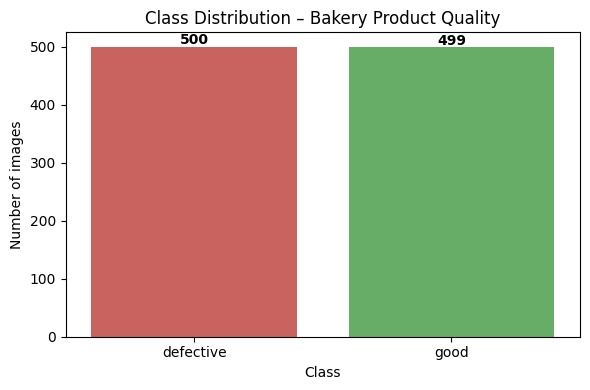

In [18]:
summary = pd.DataFrame({"Class": list(counts.keys()),
                        "Number of images": list(counts.values())})
total = summary["Number of images"].sum()
summary["Percentage"] = (summary["Number of images"] / total * 100).round(1)
print(summary.to_string(index=False))
print(f"\nTotal images : {total}")
print(f"Classes      : {len(counts)} -> {list(counts.keys())}")

plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="Class", y="Number of images",
            palette=["#d9534f", "#5cb85c"])
plt.title("Class Distribution – Bakery Product Quality")
for i, v in enumerate(summary["Number of images"]):
    plt.text(i, v + total * 0.005, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/01_class_distribution.png", dpi=150); plt.show()

## 5. Train / Validation / Test Split
Stratified **70 / 15 / 15** split written to disk.

In [19]:
def split_combined(combined_dir, out_dir, ratios=SPLIT_RATIOS, seed=SEED):
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    classes = sorted(os.listdir(combined_dir))
    for split in ("train", "val", "test"):
        for c in classes:
            os.makedirs(os.path.join(out_dir, split, c), exist_ok=True)
    for c in classes:
        files = os.listdir(os.path.join(combined_dir, c))
        train_f, temp_f = train_test_split(files, train_size=ratios[0], random_state=seed)
        val_f, test_f = train_test_split(
            temp_f, train_size=ratios[1] / (ratios[1] + ratios[2]), random_state=seed)
        for split, fs in (("train", train_f), ("val", val_f), ("test", test_f)):
            for f in fs:
                shutil.copy(os.path.join(combined_dir, c, f),
                            os.path.join(out_dir, split, c, f))

split_combined(COMBINED_DIR, SPLIT_DIR)
for split in ("train", "val", "test"):
    line = [f"{split:<6}"]
    for c in sorted(counts):
        line.append(f"{c}={len(os.listdir(os.path.join(SPLIT_DIR, split, c)))}")
    print("  ".join(line))

train   defective=350  good=349
val     defective=75  good=75
test    defective=75  good=75


## 6. Load Data, Normalize and Augment
`image_dataset_from_directory` reads, resizes and batches the images. We then
cast everything to float32 and apply augmentation **in the data pipeline** (not
inside the model) — this is the most robust pattern on TensorFlow/Keras 3.
Validation and test sets are kept **unshuffled** and **un-augmented** so
predictions line up with labels.

In [20]:
train_ds = keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False)

class_names = train_ds.class_names      # ['defective', 'good']
print("Class order:", class_names)

# Augmentation pipeline (applied to TRAIN only, in tf.data)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def _cast(x, y):
    return tf.cast(x, tf.float32), tf.cast(y, tf.float32)

def _augment(x, y):
    return data_augmentation(x, training=True), y

train_ds = train_ds.map(_cast, num_parallel_calls=AUTOTUNE).cache()
train_ds = train_ds.map(_augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(_cast, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(_cast, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

Found 699 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Class order: ['defective', 'good']


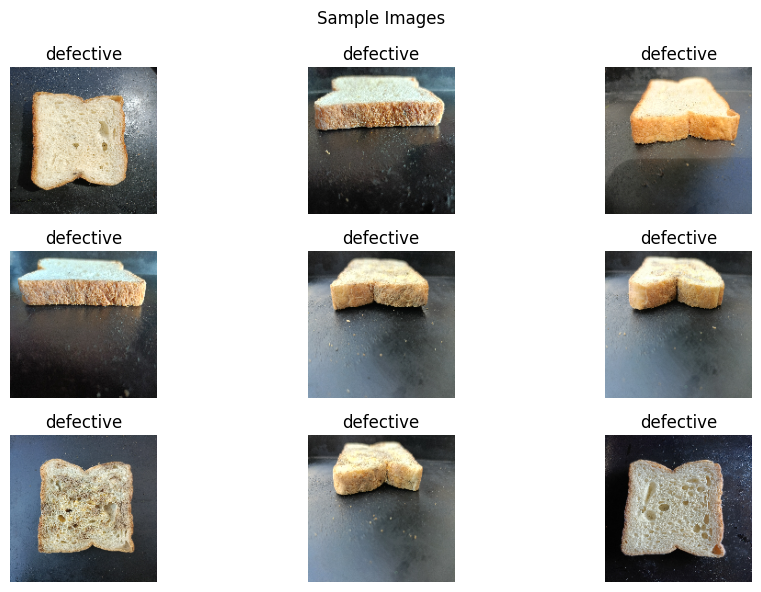

In [21]:
# Sample images (from the un-augmented validation set)
plt.figure(figsize=(10, 6))
for images, lbls in val_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(lbls[i].numpy()[0])]); plt.axis("off")
plt.suptitle("Sample Images"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_sample_images.png", dpi=150); plt.show()

## 7. Data Augmentation Preview
The same random flip / rotation / zoom / contrast that is applied to the training
data, shown on one validation image.

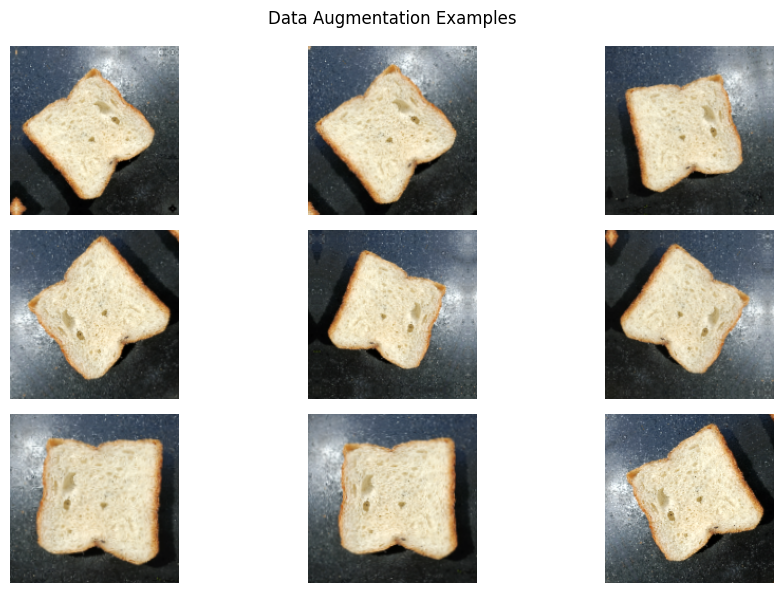

In [22]:
plt.figure(figsize=(10, 6))
for images, _ in val_ds.take(1):
    first = images[0:1]
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(data_augmentation(first, training=True)[0].numpy().astype("uint8"))
        plt.axis("off")
plt.suptitle("Data Augmentation Examples"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_augmentation.png", dpi=150); plt.show()

## 8. Custom CNN Model
Three Conv-BN-ReLU-Pool blocks + a dense head with dropout.

In [23]:
def build_cnn(input_shape=(*IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)        # normalize to [0,1]
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", name="last_conv")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="Custom_CNN")

def make_callbacks():
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                              patience=3, min_lr=1e-6)]

cnn = build_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss=keras.losses.BinaryCrossentropy(),
            metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])
cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
history_cnn = cnn.fit(train_ds, validation_data=val_ds,
                      epochs=EPOCHS_CNN, callbacks=make_callbacks())

Epoch 1/25


I0000 00:00:1780875897.198129     133 service.cc:152] XLA service 0x19a7e3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780875897.198195     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780875897.198202     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780875898.622246     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/22 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5017 - loss: 0.8206 

I0000 00:00:1780875909.107445     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7239 - loss: 0.5326 - val_accuracy: 0.5333 - val_loss: 0.6844 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8727 - loss: 0.3101 - val_accuracy: 0.6133 - val_loss: 0.6776 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9227 - loss: 0.2259 - val_accuracy: 0.5467 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9356 - loss: 0.2000 - val_accuracy: 0.4867 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9413 - loss: 0.1702 - val_accuracy: 0.5000 - val_loss: 0.6890 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9413 - loss: 0.1751 - val_accuracy: 0.5067 - val_loss: 0.6648 - learning_rate: 5.0000e-04
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9456 - loss: 0.1602 - val_accuracy: 0

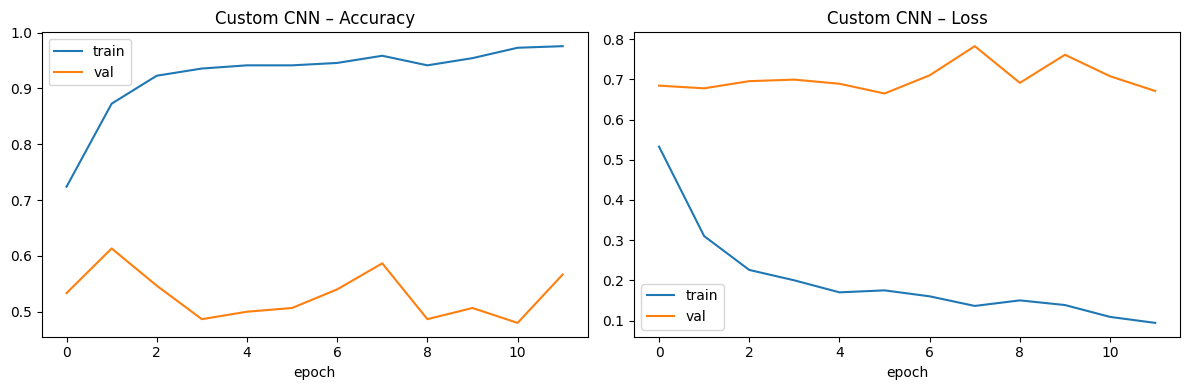

In [25]:
def plot_curves(hist, title, fname):
    h = hist if isinstance(hist, dict) else hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(f"{title} – Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{title} – Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{fname}", dpi=150); plt.show()

plot_curves(history_cnn, "Custom CNN", "04_cnn_curves.png")

## 9. Transfer Learning Models (MobileNetV2 and ResNet50)
We benchmark **two** ImageNet-pretrained backbones. Each is trained with a frozen
base (head only) and then fine-tuned (top layers unfrozen at a low learning
rate). A reusable function keeps the two models consistent.

In [26]:
def build_transfer(app_fn, preprocess_fn, name):
    base = app_fn(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
    base.trainable = False
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = preprocess_fn(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name=name), base

def _compile(model, lr):
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss=keras.losses.BinaryCrossentropy(),
                  metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])

def train_transfer(model, base):
    _compile(model, 1e-3)
    h1 = model.fit(train_ds, validation_data=val_ds,
                   epochs=EPOCHS_TL_HEAD, callbacks=make_callbacks())
    base.trainable = True                       # fine-tune top layers
    for layer in base.layers[:-30]:
        layer.trainable = False
    _compile(model, 1e-5)
    n1 = len(h1.history["loss"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=n1 + EPOCHS_TL_FT,
                   initial_epoch=n1, callbacks=make_callbacks())
    return {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12


2026-06-07 23:46:15.261283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 23:46:15.398517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5375 - loss: 0.7747

2026-06-07 23:46:27.312080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 23:46:27.448671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5405 - loss: 0.7705

2026-06-07 23:46:42.138648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 23:46:42.275438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6037 - loss: 0.6828 - val_accuracy: 0.8667 - val_loss: 0.4276 - learning_rate: 0.0010
Epoch 2/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8097 - loss: 0.4196 - val_accuracy: 0.9200 - val_loss: 0.3133 - learning_rate: 0.0010
Epoch 3/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8555 - loss: 0.3490 - val_accuracy: 0.9200 - val_loss: 0.2701 - learning_rate: 0.0010
Epoch 4/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8684 - loss: 0.2999 - val_accuracy: 0.8867 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 5/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8884 - loss: 0.2666 - val_accuracy: 0.9200 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 6/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9170 - loss: 0.2272 - val_accuracy: 0.9200 - val_loss: 0.2198 - learning_rate: 0.0010
Epoch 7/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9127 - loss: 0.2226 - val_accuracy: 0.926

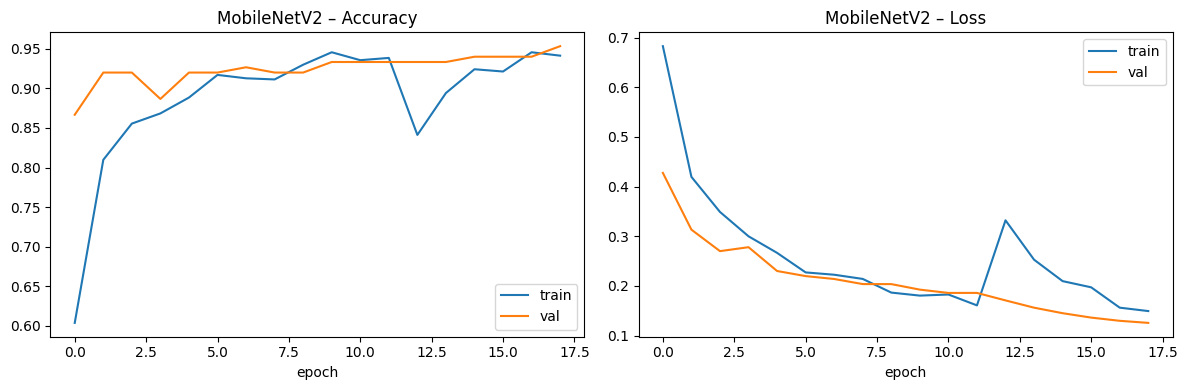

In [27]:
# MobileNetV2
mnet, mnet_base = build_transfer(
    keras.applications.MobileNetV2,
    keras.applications.mobilenet_v2.preprocess_input, "MobileNetV2")
hist_mnet = train_transfer(mnet, mnet_base)
plot_curves(hist_mnet, "MobileNetV2", "05_mobilenet_curves.png")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 686ms/step - accuracy: 0.6109 - loss: 0.7764 - val_accuracy: 0.8600 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 2/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8197 - loss: 0.4043 - val_accuracy: 0.9333 - val_loss: 0.2208 - learning_rate: 0.0010
Epoch 3/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.8798 - loss: 0.2940 - val_accuracy: 0.9467 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 4/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.9070 - loss: 0.2294 - val_accuracy: 0.9467 - val_loss: 0.1793 - learning_rate: 0.0010
Epoch 5/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.9227 - loss: 0.2083 - val_accuracy: 0.9533 - val_loss: 0.1710 - learning_rate: 0.0010
Epoch 6/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.9299 - loss: 0.1833 - val_accuracy: 0.9533 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 7/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 

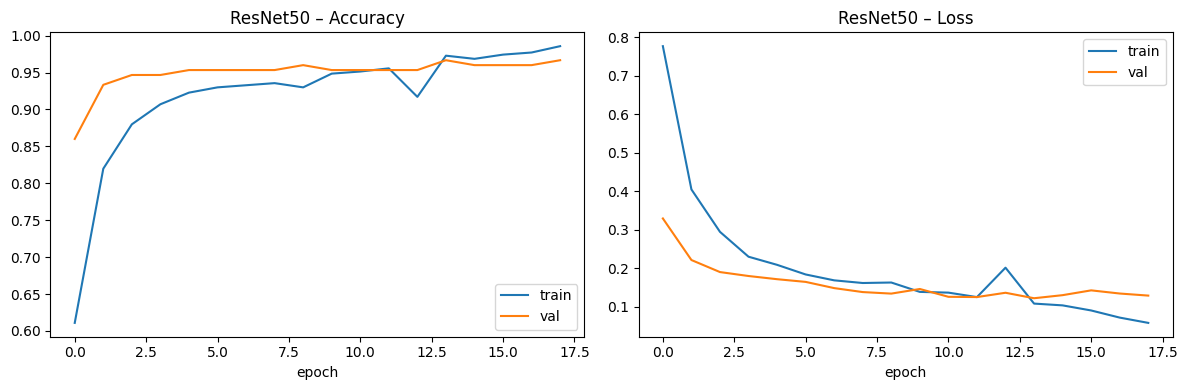

In [28]:
# ResNet50
resnet, resnet_base = build_transfer(
    keras.applications.ResNet50,
    keras.applications.resnet50.preprocess_input, "ResNet50")
hist_resnet = train_transfer(resnet, resnet_base)
plot_curves(hist_resnet, "ResNet50", "06_resnet_curves.png")

## 10. Evaluation
For every model we compute accuracy, a classification report, precision/recall/F1
(macro), confusion matrix, ROC-AUC and **average inference time per image**.


===== Custom CNN =====
Accuracy 0.5000 | Precision 0.5000 | Recall 0.5000 | F1 0.3448 | Inference 0.34 ms/img
              precision    recall  f1-score   support

   defective     0.5000    0.9867    0.6637        75
        good     0.5000    0.0133    0.0260        75

    accuracy                         0.5000       150
   macro avg     0.5000    0.5000    0.3448       150
weighted avg     0.5000    0.5000    0.3448       150



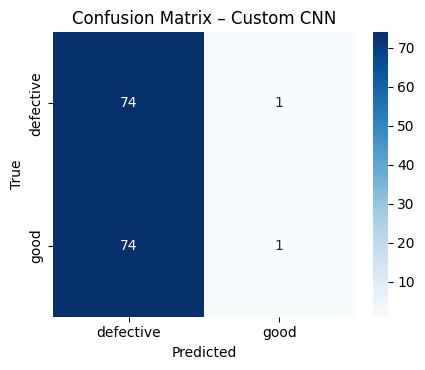


===== MobileNetV2 =====
Accuracy 0.9533 | Precision 0.9534 | Recall 0.9533 | F1 0.9533 | Inference 0.67 ms/img
              precision    recall  f1-score   support

   defective     0.9595    0.9467    0.9530        75
        good     0.9474    0.9600    0.9536        75

    accuracy                         0.9533       150
   macro avg     0.9534    0.9533    0.9533       150
weighted avg     0.9534    0.9533    0.9533       150



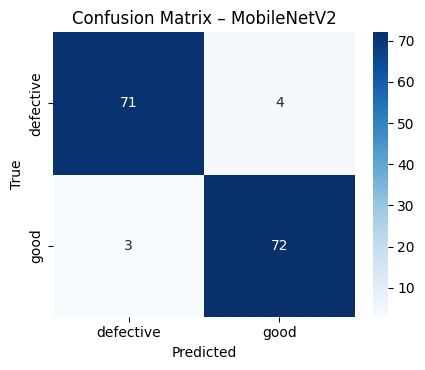


===== ResNet50 =====
Accuracy 0.9600 | Precision 0.9630 | Recall 0.9600 | F1 0.9599 | Inference 1.85 ms/img
              precision    recall  f1-score   support

   defective     0.9259    1.0000    0.9615        75
        good     1.0000    0.9200    0.9583        75

    accuracy                         0.9600       150
   macro avg     0.9630    0.9600    0.9599       150
weighted avg     0.9630    0.9600    0.9599       150



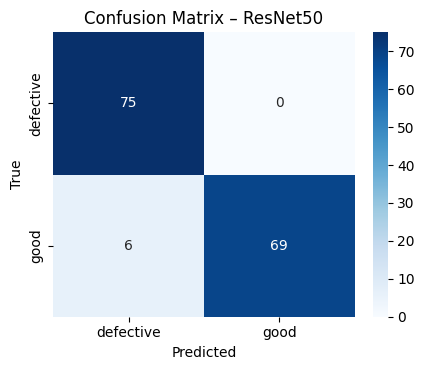

In [29]:
def get_true_probs(model, dataset):
    y_true = np.concatenate([y.numpy().ravel() for _, y in dataset]).astype(int)
    probs = model.predict(dataset, verbose=0).ravel()
    return y_true, probs

def evaluate_model(model, dataset, name, idx):
    loss, acc = model.evaluate(dataset, verbose=0)
    y_true, probs = get_true_probs(model, dataset)
    y_pred = (probs > 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)

    # inference time per image (timed over the whole test set)
    _ = model.predict(dataset.take(1), verbose=0)         # warm-up
    t0 = time.time(); _ = model.predict(dataset, verbose=0)
    infer_ms = (time.time() - t0) / len(y_true) * 1000

    print(f"\n===== {name} =====")
    print(f"Accuracy {acc:.4f} | Precision {prec:.4f} | Recall {rec:.4f} | "
          f"F1 {f1:.4f} | Inference {infer_ms:.2f} ms/img")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix – {name}")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{idx}_cm_{name}.png", dpi=150); plt.show()

    fpr, tpr, _ = roc_curve(y_true, probs); roc_auc = auc(fpr, tpr)
    return {"name": name, "accuracy": acc, "loss": loss, "precision": prec,
            "recall": rec, "f1": f1, "auc": roc_auc, "infer_ms": infer_ms,
            "y_true": y_true, "y_pred": y_pred, "probs": probs,
            "fpr": fpr, "tpr": tpr}

cnn_res    = evaluate_model(cnn,    test_ds, "Custom CNN",  "07")
mnet_res   = evaluate_model(mnet,   test_ds, "MobileNetV2", "08")
resnet_res = evaluate_model(resnet, test_ds, "ResNet50",    "09")
all_res = [cnn_res, mnet_res, resnet_res]

## 11. Model Comparison (performance + efficiency)
This directly addresses RQ2 (performance vs computational efficiency).

      Model  Accuracy  Precision  Recall     F1  ROC AUC  Inference (ms/img)
 Custom CNN    0.5000     0.5000  0.5000 0.3448   0.7925              0.3365
MobileNetV2    0.9533     0.9534  0.9533 0.9533   0.9924              0.6699
   ResNet50    0.9600     0.9630  0.9600 0.9599   0.9957              1.8499


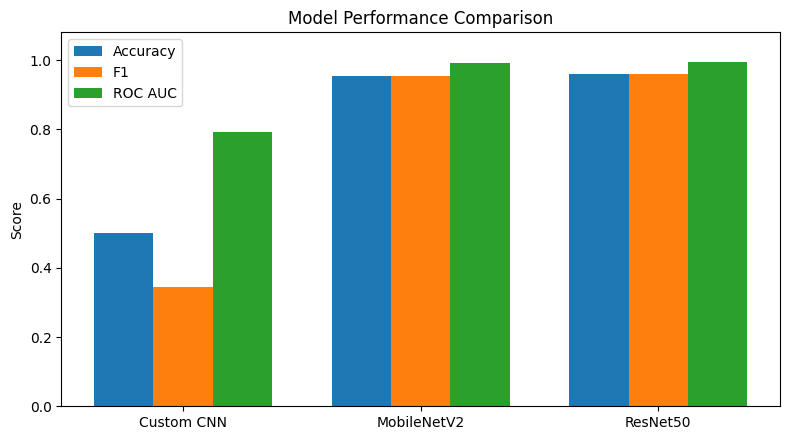

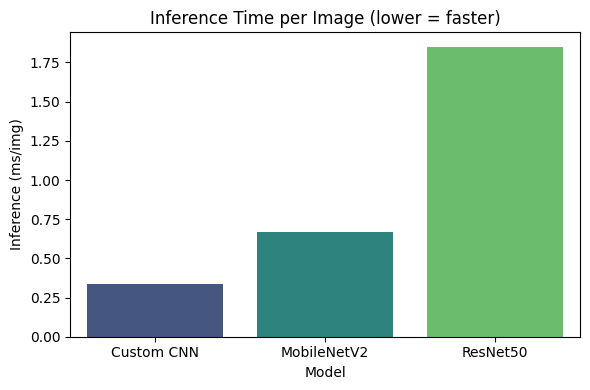

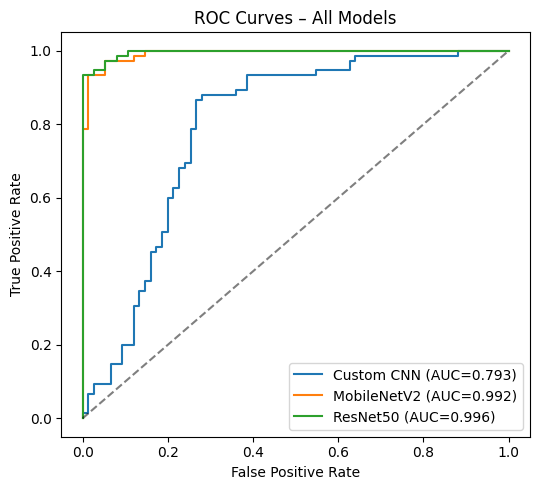

In [30]:
comparison = pd.DataFrame([{
    "Model": r["name"], "Accuracy": r["accuracy"], "Precision": r["precision"],
    "Recall": r["recall"], "F1": r["f1"], "ROC AUC": r["auc"],
    "Inference (ms/img)": r["infer_ms"]} for r in all_res]).round(4)
print(comparison.to_string(index=False))
comparison.to_csv(f"{FIG_DIR}/model_comparison.csv", index=False)

# Accuracy / F1 / AUC grouped bars
metrics = ["Accuracy", "F1", "ROC AUC"]
x = np.arange(len(comparison)); w = 0.25
plt.figure(figsize=(8, 4.5))
for i, m in enumerate(metrics):
    plt.bar(x + (i - 1) * w, comparison[m], w, label=m)
plt.xticks(x, comparison["Model"]); plt.ylim(0, 1.08); plt.ylabel("Score")
plt.title("Model Performance Comparison"); plt.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/10_model_comparison.png", dpi=150); plt.show()

# Inference-time comparison (efficiency)
plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x="Model", y="Inference (ms/img)", palette="viridis")
plt.title("Inference Time per Image (lower = faster)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/11_inference_time.png", dpi=150); plt.show()

# Combined ROC curves
plt.figure(figsize=(5.5, 5))
for r in all_res:
    plt.plot(r["fpr"], r["tpr"], label=f"{r['name']} (AUC={r['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/12_roc_all.png", dpi=150); plt.show()

## 12. Grad-CAM Explainability (correct, false positive, false negative)
Grad-CAM highlights the regions the **custom CNN** used. As required, we show one
**correct** prediction, one **false positive** and one **false negative** so we
can judge whether the model attends to meaningful regions (RQ4).

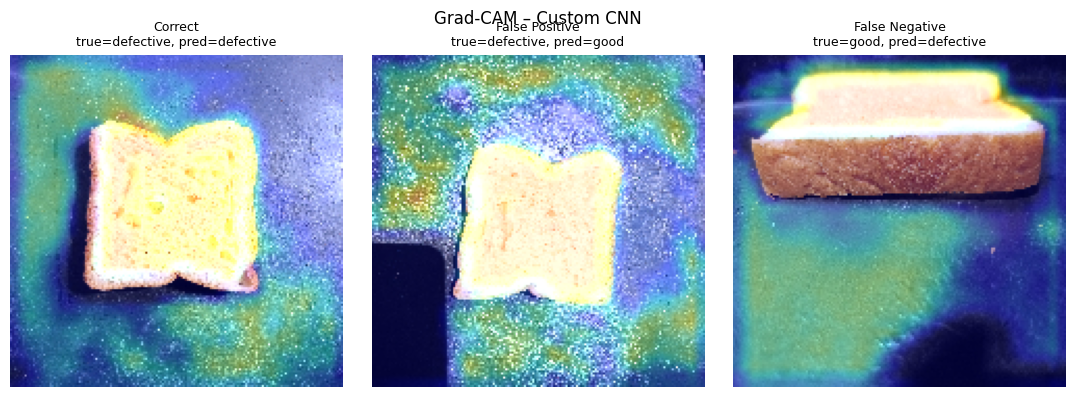

In [31]:
def make_gradcam(img_array, model, last_conv="last_conv"):
    grad_model = keras.models.Model(model.inputs,
                    [model.get_layer(last_conv).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heat = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    return heat.numpy()

def overlay(img, heat):
    heat = np.uint8(255 * heat)
    jet = cm.get_cmap("jet")(np.arange(256))[:, :3][heat]
    jet = keras.utils.array_to_img(jet).resize((IMG_SIZE[1], IMG_SIZE[0]))
    jet = keras.utils.img_to_array(jet)
    return np.clip(jet * 0.4 + img, 0, 255).astype("uint8")

# rebuild ordered test images + use the CNN predictions
test_images = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
yt, yp = cnn_res["y_true"], cnn_res["y_pred"]
# positive class = 'good' (index 1)
cases = {
    "Correct":        np.where(yt == yp)[0],
    "False Positive": np.where((yp == 1) & (yt == 0))[0],  # predicted good, was defective
    "False Negative": np.where((yp == 0) & (yt == 1))[0],  # predicted defective, was good
}
plt.figure(figsize=(11, 4))
for i, (label, idxs) in enumerate(cases.items()):
    plt.subplot(1, 3, i + 1)
    if len(idxs) == 0:
        plt.text(0.5, 0.5, f"No {label}\ncases", ha="center"); plt.axis("off"); continue
    j = int(idxs[0]); img = test_images[j]
    heat = make_gradcam(img[np.newaxis, ...], cnn)
    plt.imshow(overlay(img, heat))
    plt.title(f"{label}\ntrue={class_names[yt[j]]}, pred={class_names[yp[j]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Grad-CAM – Custom CNN"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_gradcam_cases.png", dpi=150); plt.show()

## 13. Error Analysis
Misclassified test images from the best model, for the report's discussion of
failure patterns (RQ5).

Best model: ResNet50
Misclassified: 6 / 150


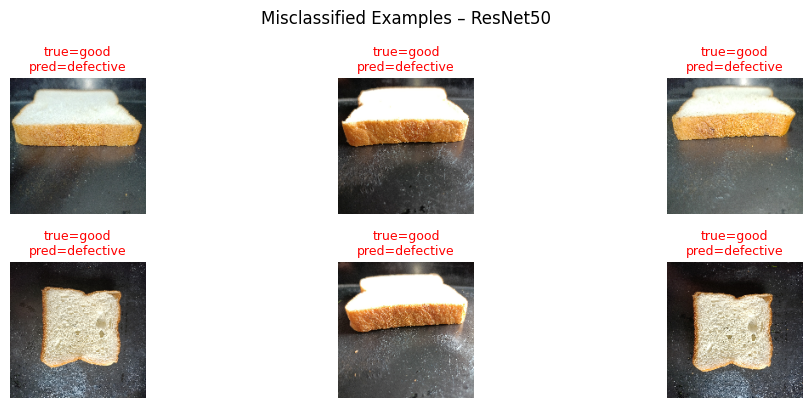

In [32]:
best = max(all_res, key=lambda r: r["accuracy"])
print("Best model:", best["name"])
yt, yp = best["y_true"], best["y_pred"]
wrong = np.where(yt != yp)[0]
print(f"Misclassified: {len(wrong)} / {len(yt)}")
plt.figure(figsize=(10, 6))
for i, j in enumerate(wrong[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[j].astype("uint8"))
    plt.title(f"true={class_names[yt[j]]}\npred={class_names[yp[j]]}",
              fontsize=9, color="red"); plt.axis("off")
plt.suptitle(f"Misclassified Examples – {best['name']}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_error_analysis.png", dpi=150); plt.show()

## 14. Save Models

In [33]:
cnn.save(f"{MODEL_DIR}/custom_cnn.keras")
mnet.save(f"{MODEL_DIR}/mobilenetv2.keras")
resnet.save(f"{MODEL_DIR}/resnet50.keras")
print("Saved models and figures to /kaggle/working/")
for f in sorted(os.listdir(FIG_DIR)):
    print("  figures/", f)

Saved models and figures to /kaggle/working/
  figures/ 01_class_distribution.png
  figures/ 02_sample_images.png
  figures/ 03_augmentation.png
  figures/ 04_cnn_curves.png
  figures/ 05_mobilenet_curves.png
  figures/ 06_resnet_curves.png
  figures/ 07_cm_Custom CNN.png
  figures/ 08_cm_MobileNetV2.png
  figures/ 09_cm_ResNet50.png
  figures/ 10_model_comparison.png
  figures/ 11_inference_time.png
  figures/ 12_roc_all.png
  figures/ 13_gradcam_cases.png
  figures/ 14_error_analysis.png
  figures/ model_comparison.csv


## 15. Deployment, Limitations and Ethics (for the report)
- **Deployment as screening tool:** intended to *assist* human inspectors on a
  production line by flagging likely-defective items for review, not to replace
  them. A confidence threshold can route uncertain cases to a human.
- **Limitations:** single product type (egg bread toast), modest dataset size,
  images captured under limited conditions; performance may drop on new bakeries,
  lighting, or product types (domain shift).
- **Class imbalance:** mild (≈56/44); handled via augmentation and reported with
  per-class precision/recall/F1, not accuracy alone.
- **Ethical / safety concerns:** a false "good" prediction could pass a defective
  product, so in a food-safety setting the system must stay advisory with human
  sign-off; it should be revalidated on real production data before any use.
- **Future work:** larger and more varied data, more product types, calibration
  of confidence, and on-line validation against expert labels.